# Python Introduction - 4 - Numpy and linear algebra, intro to Matplotlib

*Basics of Cognitive Science*

This notebook contains information and exercises for the basic libraries *numpy* and *Matplotlib* (for making plots). Per convention numpy is abbreviated with `np` and matplotlib with `plt`. <br>

Note: we will be introducing making figures intermixed with the info/exercises on numpy without necessarily going into too much detail about the plotting. Often you will be able to work out what a command does from the call itself. Where this is not the case this is a good way to practice looking up relevant information in the documentation.

In [18]:
# we will start with our imports
import numpy as np 
import matplotlib.pyplot as plt


#Note: should your plots open in separate windows, instead of in the notebook itself, you will want to uncomment the following line:
#%matplotlib inline

## 1. On random numbers using numpy

In Cognitive Science we often make use of random numbers, e.g. for simulating certain processes, they account for all the variables we do not directly control in a model or experimental procedure.

Below we will highlight a few different (but not all!) random number functions that are commonly used, and the differences between them.

You have already seen some functions of them that work on a global level. It can often be better to create an instance of a random generator that can be tracked more specifically. This prevents interference with other packages that might also rely on random numbers. Below we will use such an instance of a random number generator and go through its methods for generating different variations of random samples.

In [17]:
# create an instance of a random number generetor
rng = np.random.default_rng()

# we can also give it a seed: a seed gives the random generator a specific starting point.
# Whenever you give the same seed at start you will get the same "random" sequence afterwards
rng2 = np.random.default_rng(42)
rng3 = np.random.default_rng(42)

We can use our random generator instance to then get random numbers from this particular instance. Below an example were we will get a first random sequences from each of the three generator instances defined above....

In [8]:
# the generator set with a random seed (no seed given as input)
print(rng.random(10))
print('-------')

# the following two statements should lead to the same "random" sequence as they both use the same starting point/seed
print( rng2.random(10) )
print('---- ... should be the same as ... ---')
print( rng3.random(10) )


[0.23600102 0.09414905 0.35679804 0.75494701 0.14269391 0.63087051
 0.46238729 0.24711834 0.50562086 0.752957  ]
-------
[0.77395605 0.43887844 0.85859792 0.69736803 0.09417735 0.97562235
 0.7611397  0.78606431 0.12811363 0.45038594]
---- ... should be the same as ... ---
[0.77395605 0.43887844 0.85859792 0.69736803 0.09417735 0.97562235
 0.7611397  0.78606431 0.12811363 0.45038594]


## 2. Random Numbers from Uniform Distributions

We can now use the random generator's method `random()` to provide random real numbers between 0 and 1 (1 not included) on a so-called `uniform distribution` for that range which means that all values in the range have equal chance to be drawn.

In [6]:
# generate 1000 random values between 0 and 1
sample1000 = rng.random(1000)

In [5]:
# check the type of the numbers inside the array, here should be some kind of float
sample1000.dtype

dtype('float64')

If all values have equal chance to be drawn, this means that for a large sample of random numbers each possible number should roughly occur equally often.

We will illustrate this below by drawing a large number of random numbers and then plot a histogram of the results (using matplotlib)

Text(0, 0.5, 'count')

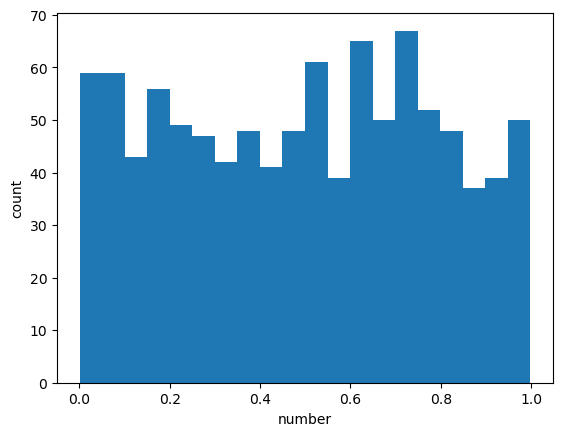

In [16]:
#plot the sample in a histogram; bins = 20 splits the numbers into 20 separate bins for the count
plt.hist(sample1000,bins = 20) # make a histogram of the values in sample1000
plt.xlabel('number') # add a label on the x-axis
plt.ylabel('count')  # add a label on the y axis

### Exercise 1:

How would you go about generating random numbers on the range 0 to 2 (instead of 0 to 1)? There are multiple ways to do this.

In [28]:
# Code here
sample1000 = np.random.uniform(0,2,1000)
sample1000 = 2 * np.random.rand(1000)


### Exercise 2:

There is also the `integers` function that draws random integers in an interval:

In [30]:
# Provides a random integer between 0 and 4
# To draw multiple random values with one command we can use the input variable size to indicate how many:
int1000 = rng.integers(5, size = (1000))

# check the type of the numbers inside the array, here should be some kind of int
print(int1000.dtype)

int64


Text(0, 0.5, 'count')

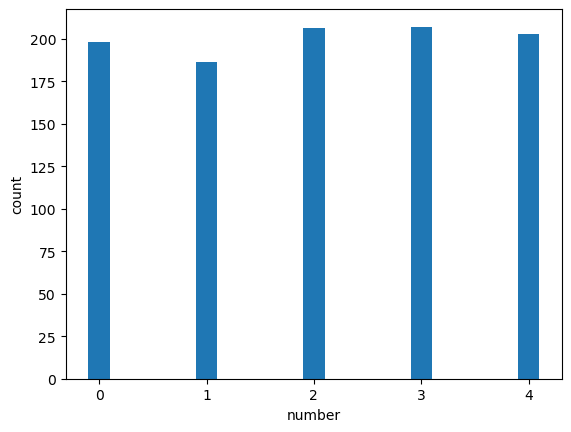

In [19]:
# plot the sample in a histogram; bins = [] specifies the edges of the bins to uses

plt.hist(int1000,bins = np.arange(-0.1,4.3,0.2))
plt.xlabel('number')
plt.ylabel('count')

# Note we have here also introduced the command np.arange():
# This function is very similar to range except that it can also deal with real numbers.
# The output of np.arange is of course also a numpy array

Look up and try out how to change the range within which to draw the random numbers from. For instance: draw a random integer sample with mimimal possible value = 3 and maximum value = 7

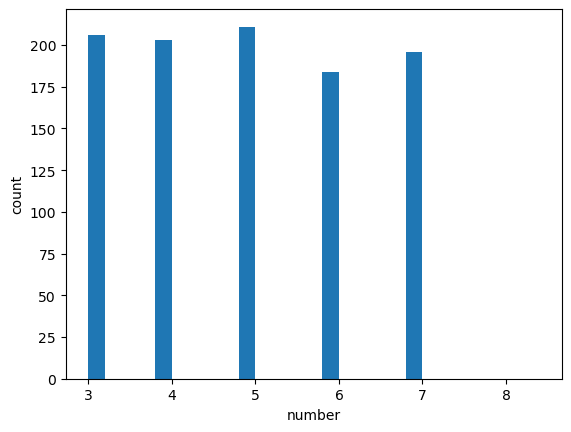

In [ ]:
sample1000 = rng.integers(3,8, size = (1000)) #8 Obergrenze die nicht erreicht wird
plt.hist(sample1000, bins= np.arange(3,8.5,0.2)) #0.2 Breite des Balkens
plt.xlabel('number')
plt.ylabel('count')
plt.show()


### Exercise 3:

Write a function `diceroll()` that can simulate a dice roll. The dice should be fair, i.e. all possible events (numbers 1,2,3,4,5,6) should occur with equal probability. 

**Hints:**
* Use numpy. See useful functions above
* Try to use a single short call to a numpy function within your dice roll function
* There are several ways to accomplish this task in Python using NumPy.

In [ ]:
# your function: write your function here
def diceroll(n):
    return rng.integers(1,7,size = (n)) 


Text(0, 0.5, 'count')

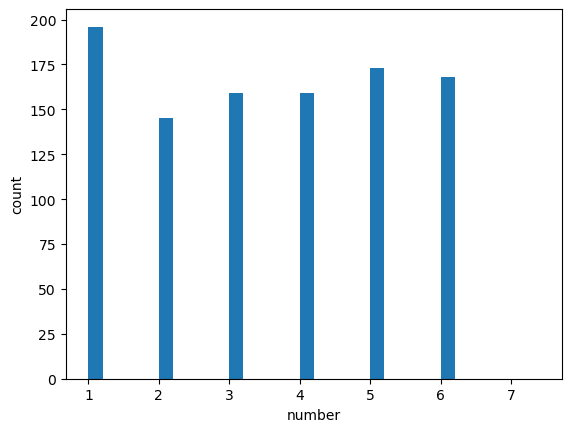

In [54]:
# tests: here you can write code that tests if your function works the way it is supposed to 
rolls = diceroll(1000)
plt.hist(rolls, bins = np.arange(1,7.5,0.2))
plt.xlabel('number')
plt.ylabel('count') 

In [ ]:
# plot the sample in a histogram; bins = [] specifies the edges of the bins to uses

## 3. Random Numbers from Standard Normal Distributions

For simulating certain processes (e.g. human perception and behaviour) it can be useful to draw numbers from a different distribution. For many types of measurements the distribution of sample will often be `normal` or `Gaussian` meaning that values close to the mean occur more often than samples further away.

The Normal Distribution is a Gaussian distribution with mean = 0 and standard deviation = 1. `standard_normal()` draws random number from this distribution.

In [ ]:
# draw 1000 random numbers from a normal distribution with mean 0 and std 1
normal1000 = rng.standard_normal(1000)

In [ ]:
#plot the sample in a histogram
histdata = plt.hist(normal1000,bins = 20)   # add output that has the counts for the bins (index 0), and the bin edges (index 1)
# plot plots a line with inputs 'x' for the x-values and 'y' for the y-values the line should follow (in order)
plt.plot([0,0],[0,np.max(histdata[0])],'k-')    # plot black ('k') line ('-') to indicate the mean of 0
plt.plot([-1,-1],[0,np.max(histdata[0])],'b--')   # plot blue ('b') dashed ('--') line to indicate at the location of -sigma
plt.plot([1,1],[0,np.max(histdata[0])],'b--')     # plot blue ('b') dashed ('--') line to indicate the mean of +sigma
plt.xlabel('number')
plt.ylabel('count')

### Exercise 1: 

How would you go about getting a random sample from a Gaussian distribution with mean = 7 and std = 3? (again there are multiple solutions for this)

In [ ]:
# Code here

## 4. Shuffle and Permuted Given Numbers

`shuffle` and `permutated` do not really return random numbers as such. Rather they can take as input an array of numbers and randomly shuffle the order of the values in it:

Note, you may wonder what the use of these functions is, but this can for instance be particularly useful shuffling the order of certain conditions when running experiments.

In [ ]:
# example using shuffle
x = np.arange(0,10,1)
y = x.copy()           # If we want to leave the original array intact we need to make a copy of x
# note if we used y = x then anything we do to y also happens to x (that is y becomes sort of a "pointer" to x)
rng.shuffle(y)         # shuffle our copy y

# the same idea using permutation instead
y2 = rng.permuted(x)   # does not need the copy to have an independent y2

print(x)
print(y)
print(y2)

# plot y against x, for both options using 1x2 subpanels
fig, axs = plt.subplots(1, 2, figsize=(8, 4))
# axs now has the handels to the separate "subplots" or "panels"
# make the "shuffle" plot on the left side: handle axs[0]
axs[0].plot(x,y,'o')                    # plot y against x using circles ('o') as symbols
axs[0].set_xlabel('x')                  # note: we are now acting on the axes handles -> some commands are slightly different
axs[0].set_ylabel('shuffled x')
axs[0].set_title('np.random.shuffle')   # add a figure title

# make the "permutation" plot on the right side: handle axs[1]
axs[1].plot(x,y2,'o')
axs[1].set_xlabel('x')
axs[1].set_ylabel('permuted x')
axs[1].set_title('np.random.permutation')



## 5. Linear Algebra with Numpy

Numpy is particularly useful when needing linear algebra operations in Python. It is a bit beyond the scope of this course to cover every possible algebraic operation that you can do with numpy here. Instead we will cover the most common and relevant ones.

(note: when starting the perceptron assignment you may want to revisit some of this).

In [ ]:
# first we define some matrices and vectors that we can use
# remember the definitions from last week, look up in docs or print the results
mat1 = np.diag(np.array([2,5,3]))           # a 3x3 matrix
mat2 = np.array([[1,2,3],[4,5,6],[7,8,9]])  # a 3x3 matrix
mat3 = np.ones((3,3))-np.eye(3)             # a 3x3 matrix
mat4 = rng.integers(6,size = (2,4))         # a 2 by 4 matrix
mat5 = rng.integers(6,size = (4,2))         # a 4 by 2 matrix
mat6 = np.empty_like(mat5)                  # "empty" matrix with the same shape as mat5 (see also np.empty from last week)

vec0 = np.array([[5],[2],[4]])              # a vertical vector
vec1 = np.array([[0],[2],[3]])              # another vertical vector
vec2 = np.array([[4,1,2]])                  # a horizontal vector
vec3 = np.array([5,2,4])                    # vector without an explicit 2nd dimension

Revisiting simple operations

Below some very simple operations (e.g. adding, subtracting etc).

In [ ]:
# adding matrices
print(mat1 + mat2)
print('---')

# subtracting
print(mat2 - mat3)
print('---')

# multiplying with a scalar
print(3*mat1)
print('---')

# multiplying matrices: matrix multiplaction from algebra (see also np.matmul and np.dot)
print(mat1@mat3)
print('---')

# the same as the directly above:
print(np.matmul(mat1,mat3))

# which is different from element-wise multiplication (see also np.multiply)
print(mat1*mat3)
print('---')



In [ ]:
# same with vectors: 
print(vec0+vec1)
print('---')

print(vec0-vec1)
print('---')

print(vec0*vec1)
print('---')

print(vec2@vec1)

In [ ]:
# note the requirements for the dimensions for different operations
# adding matrices the dimensions should be equal. i.e. the following does not work
mat1 + mat4

In [ ]:
# this also does not work
mat1@mat4

In [ ]:
# this does for a matrix "operating on" a vector 
print(mat3@vec1)
print('---')

# and this does
print(mat4@mat5)
print('---')

# and this does
print(mat5@mat4)
print('---')

# this however does not work as the vector has the wrong shape (horizontal instead of vertical)
print(mat3@vec2)
print('---')
# the following is ambiguous as the shape of the vector vec3 is not fully specified but would work
# print(mat3@vec3)

# In any case in linear algebra the shape of the components and the order matters for matrix multiplications! i.e. A@B != B@A

Sometimes it is useful to see a matrix as a collection of vectors. Here is an example of how...

The example uses the following operation from linear algebra to implement a rotation of a point (x,y):

$\begin{bmatrix}
x' \\
y'
\end{bmatrix} = 
\begin{bmatrix}
\cos (\alpha) & -\sin(\alpha) \\
\sin( \alpha) & \cos(\alpha)
\end{bmatrix}
\begin{bmatrix}
x \\
y
\end{bmatrix}
$

The features mentioned allows us to do this operation on a whole set of points at once, rather than having to go point by point in a loop.

In [ ]:
# this example will rotate a set of datapoints all in one go

# create matrix that represents a rotation operation
alpha = np.deg2rad(5)      # angle by which to rotate converted from degrees to radians
rotmat = np.array([[np.cos(alpha),-np.sin(alpha)],
                   [np.sin(alpha),np.cos(alpha)]]) # rotation matrix around origin using sine and cosine functions

# let's also assume we have a list x and y data points that we want to rotate by angle alpha
datapoints = rng.integers(11,size=(2,20))-5 # here some random x-y coordinates

# now rotate all the datapoints around the origin in one go rather than needing a loop to iterate through each datapoint
rotData = rotmat@datapoints # treats each column in datapoints as a separate vector, i.e. here datapoint
# this may not be what you expected from a pure algebraic sense but can be a useful feature as you see

# -------------------------------------------------------------------------
# that one line "rotData = rotmat@datapoints" is in this case equivalent to the following
rotData2 = np.empty_like(datapoints, dtype = float) # generates array with same shape as datapoints
for jj in range(0,datapoints.shape[1]):
    curpoint = datapoints[:,jj]       # get the current x, y datapoint
    rotData2[:,jj] = rotmat@curpoint  # do the rotation of that datapoint and put result in rotData2
# -------------------------------------------------------------------------

# check if values from both methods are equal
rotData == rotData2

In [ ]:
# let's plot the original "datapoints" and their rotation versions in one plot
# plot the original list in red
plt.plot(datapoints[0,:],datapoints[1,:],'ro',label = "original") # the label option is useful when needing a legend
# plot the rotated list as yellow diamonds ('yd') (see documentation for plot options)
plt.plot(rotData[0,:],rotData[1,:],'yd',label = "rotated")
plt.plot(0,0,'k+')                              # plot the pivot point for the rotation       
plt.xlim(-6, 6)                                 # set x-axis to display data between the interval -6 to 6
plt.ylim(-6, 6)                                 # set y-axis to display data between the interval -6 to 6
plt.legend()                                    # add a legend using the labels above (look up legend in the documentation for options)
ax = plt.gca()                                  # get the handle to the current plot
ax.set_aspect('equal', adjustable='box')        # using this we can also set the physical dimensions of the plot to be equal
plt.draw()                                      # explicit command to draw everything from the commands above this point

Numpy has many other useful functions for algebraic calculation such that we won't be able to cover all of them (for more information see also the numpy [`linalg` submodule](https://numpy.org/doc/stable/reference/routines.linalg.html)). In the ReadingMaterials you will find a list of a few more. If you are not familiar with linear algebra it might make sense to freshen up your knowledge.

## 6. Descriptive Stats with Numpy

Numpy also has a number of useful functions for providing desciptive stats based on your arrays. For a matix mat defined as follows: <br>
`mat = np.array([[1,5,4],[3,7,9],[0,2,8]])`

The following will provide:
- the mean: `mat.mean()`
- the minimum value: `mat.min()`
- the maximum value: `mat.max()`
- the standard deviation: `mat.std()`
- the median: `np.median(mat)`
- some percentiles e.g. 25%, 50% and 75%: `np.percentile(mat,[25,50,75])`

You can also use the option `axis` the specify the dimension to do this along, instead of doing it across the whole matrix.
For instance:

`mat.mean(axis = 0)` takes the mean across the different rows for each separate column. <br>
`mat.mean(axis = 1)` takes the mean across the columns for each separate row.


In [ ]:
mat = np.array([[1,5,4],[3,7,9],[0,2,8]])
print(mat)
print('-----')
print(mat.mean(axis = 0))
print('-----')
print(mat.mean(axis = 1))

### Exercise 1:

Suppose we have the following "data-set" `data` as defined below. We will use this to do some exercise with some linear algebra methods from above, getting some basic stats and plotting our results.

In [ ]:
data = np.array([[0.82361102, 0.76946124],
       [0.38888318, 0.17903273],
       [0.17479028, 0.35101092],
       [0.73531075, 0.44546524],
       [0.65148883, 0.07574638],
       [0.76556474, 0.59588584],
       [0.13194313, 0.89020686],
       [0.96397976, 0.10872332],
       [0.69780621, 0.4050666 ],
       [0.61087508, 0.87037923],
       [0.59126965, 0.75540435],
       [0.21141105, 0.77113064],
       [0.83798497, 0.02813689],
       [0.45453437, 0.33993989],
       [0.67641654, 0.32680833],
       [0.17810607, 0.26382401],
       [0.05831168, 0.09153443],
       [0.93094803, 0.41902858],
       [0.34522157, 0.80302077],
       [0.65441834, 0.70522536]])

1.1: Getting some stats

Assume that each row contains two values that we want to average. Create a numpy array that contains the averages for each of the rows (the resulting array should contain 20 values). <br>
Call the result `standard_means`

Hint:
- see above: you should be able to do this with a single numpy command (no loop needed)

In [ ]:
# Code here

1.2: Getting weighted averages

Now let's assume that we want to weight the two values in each row differently. For instance we want to weigh the value in the first column with 75% and the other value in the second column with 25%.

Such weights can be defined as: <br>
`weights = np.array([0.75,0.25])`

Now use these weights to compute the weighted averages for each of the rows (you should again have an array with 20 values at the end of this). <br>
Call this result `weighted_means`

hint:
- you can use one of the "Other useful algebraic functions" here to do this in one go without needing a loop. Can you think of which one?

In [ ]:
# your code

1.3: Plotting the results of both means

Plot the weighted_means against the standard_means in a scatterplot.

hints:
- you can use the examples in this notebook to get an idea of which plotting functions could be useful here.
- Check the documentation of matplotlib for more information on each of the functions.

In [ ]:
# your code

1.4: discovering more plots

Now lets say we wanted to plot our `standard_means` array on the y-axis against the indices on the x-axis, but also include some measure of variability in the plot (e.g. the standard deviaton).
- Look up in the matplotlib documentation how you can add error bars to a plot (hint: this is a particular plot function in matplotlib).
- Next, make the plot indicated above with indices on the x-axis, the standard means on the y-axis, and the standard deviations for those means as error bars in the plot

In [ ]:
# your code

1.5: discovering more functions

We only covered a handful of functions that are available to you. Here we will also go a bit beyond what was covered.

If you managed to complete exercise 3.3 you should have a plot that shows a positively increasing trend between the two types of averages. See if you can find a command that you could use to obtain the correlation between the two types of averages (`standard_means` and `weighted_means`).

Hints:
- You can use google to find a numpy command that would be suitable for this.
- Beyond numpy, packages like [SciPy](https://docs.scipy.org/doc/scipy/reference/) (which stands for Scientific Python) can also provide useful functions for such tasks. If you use this, don't forget that this package will also need to be imported.

In [ ]:
# your code

## 7. Extending/merging numpy arrays

Besides algebraic calculations numpy arrays are also often used to represent numerical data. In this case we sometimes want to put different data samples together into one bigger array rather than multiple separate ones.

There are several different functions that can help with this. Here rather than introducing them in full here, let's practice looking up how to do this in the documentations.

You might want to explore the following functions:
- `stack()`
- `vstack()`
- `hstack()`
- `concatenate()`
- `append()`


### Exercise 1:




Below we will define some matrices to practice the linear albebra and stacking in the different exercises

In [ ]:
mat = np.array([[1,2,3],
                [4,5,6],
                [7,8,9]]) 
rand_rows = rng.random((6,3))
rand_columns = rng.integers(3,8, size = (9,4))

In [ ]:
rand_columns

1.1: Merging of arrays

Merge the `rand_rows` to `mat`. The *rows* of `rand_mat` should follow below those of `mat`. Call this merged array `merge1`

**Hint**:
* Look for this into the function `np.concatenate` or alternatively a function related to above used `np.vstack`.
  * Can you guess what the 'v' in 'vstack' stands for? ;)

In [ ]:
# Code here

1.2: Types in np.arrays

Check: what is the type of the numbers inside `mat` and what that of `merge1`. Is this what you expected?

In [ ]:
# Code here

1.3. More Merging

Now the `rand_columns` to your newly created array `merge1`. The *columns* of `rand_columns` should follow after those of `merge1`.
Call the result of this `merge2`

**Hint**:
* Look for this into the function `np.concatenate` or alternatively a function related to above `np.hstack`.
  * What do you think the 'h' in 'hstack' stands for? ;)

In [ ]:
# Code here

1.4: More More Merging

In the above we followed a particular order. What would have happened if we first tried to merge `rand_columns` into our initial matrix `mat` and then `rand_rows`? Would that have worked?

Try it out...

In [ ]:
# Code here